In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

import shap
shap.initjs()  # Required for notebook rendering

DATA_PROCESSED = Path('../data/processed/')
MODELS_PATH    = Path('../models/')
FIGURES_PATH   = Path('../notebooks/figures/')

print("All imports successful")
print(f"  SHAP version : {shap.__version__}")

All imports successful
  SHAP version : 0.51.0


In [3]:
print("── LOADING MODEL ARTIFACTS ──")

# Load preprocessor and model
preprocessor = joblib.load(MODELS_PATH / 'preprocessor_v1.pkl')
model        = joblib.load(MODELS_PATH / 'xgboost_v1.pkl')

# Load metadata
with open(MODELS_PATH / 'model_metadata.json') as f:
    metadata = json.load(f)

# Load feature names
with open(DATA_PROCESSED / 'feature_names.json') as f:
    feature_names = json.load(f)

# Load test data
X = pd.read_parquet(DATA_PROCESSED / 'X_features.parquet')
y = pd.read_parquet(DATA_PROCESSED / 'y_target.parquet')['churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocess test data
X_test_proc  = preprocessor.transform(X_test)
X_train_proc = preprocessor.transform(X_train)

# Get preprocessed feature names
try:
    proc_feature_names = preprocessor.get_feature_names_out()
    proc_feature_names = [
        n.replace('num__', '').replace('bin__', '')
         .replace('ord__', '').replace('ohe__', '')
         .replace('remainder__', '')
        for n in proc_feature_names
    ]
except Exception:
    proc_feature_names = feature_names

print(f"Model loaded     : {metadata['model_name']}")
print(f"AUC-ROC          : {metadata['auc_roc']}")
print(f"F1 Score         : {metadata['f1_score']}")
print(f"Threshold        : {metadata['optimal_threshold']}")
print(f"Test set size    : {X_test.shape[0]:,} rows")
print(f"Features         : {X_test_proc.shape[1]}")

── LOADING MODEL ARTIFACTS ──
Model loaded     : xgboost_v1
AUC-ROC          : 0.861
F1 Score         : 0.7813
Threshold        : 0.47
Test set size    : 3,005 rows
Features         : 36


In [4]:
print("── CREATING SHAP TREE EXPLAINER ──")
print("TreeExplainer is exact and fast for XGBoost.")
print("Much faster than KernelExplainer.\n")

# Create explainer — this is the expensive step
# TreeExplainer uses the model structure directly
# No approximation — exact Shapley values
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="interventional",
    data=X_train_proc[:500]   # background dataset
)

# Compute SHAP values for test set
# Use a sample for speed — 1000 rows is enough for analysis
SAMPLE_SIZE = 1000
np.random.seed(42)
sample_idx = np.random.choice(
    len(X_test_proc), size=SAMPLE_SIZE, replace=False
)

X_test_sample      = X_test_proc[sample_idx]
y_test_sample      = y_test.iloc[sample_idx].values

print(f"Computing SHAP values for {SAMPLE_SIZE} samples...")
shap_values = explainer.shap_values(X_test_sample)

print(f"\nSHAP values computed successfully")
print(f"Shape of shap_values : {np.array(shap_values).shape}")
print(f"Base value (E[f(x)]) : {explainer.expected_value:.4f}")
print(f"→ This is the model's average prediction across all data")

── CREATING SHAP TREE EXPLAINER ──
TreeExplainer is exact and fast for XGBoost.
Much faster than KernelExplainer.

Computing SHAP values for 1000 samples...

SHAP values computed successfully
Shape of shap_values : (1000, 36)
Base value (E[f(x)]) : 0.1296
→ This is the model's average prediction across all data


In [5]:
print("── SHAP VALUES EXPLAINED ──")
print()

# Pick one specific customer to explain
customer_idx = 0
customer_shap = shap_values[customer_idx]
customer_pred = model.predict_proba(
    X_test_sample[customer_idx:customer_idx+1]
)[:, 1][0]
customer_label = y_test_sample[customer_idx]

print(f"Customer index      : {customer_idx}")
print(f"Actual label        : "
      f"{'CHURNED' if customer_label == 1 else 'STAYED'}")
print(f"Predicted prob      : {customer_pred:.4f}")
print(f"Base value          : {explainer.expected_value:.4f}")
print(f"Sum of SHAP values  : {customer_shap.sum():.4f}")
print(f"Base + SHAP sum     : "
      f"{explainer.expected_value + customer_shap.sum():.4f}")
print()
print("→ Base value + sum of all SHAP values = prediction")
print("→ This is the fundamental SHAP property (efficiency)")

# Show top contributors for this customer
shap_df = pd.DataFrame({
    'feature'    : proc_feature_names[:len(customer_shap)],
    'shap_value' : customer_shap,
    'direction'  : [
        '↑ increases churn' if v > 0
        else '↓ decreases churn'
        for v in customer_shap
    ]
}).sort_values('shap_value', key=abs, ascending=False)

print(f"\nTop 10 feature contributions for this customer :")
print(shap_df.head(10).to_string(index=False))

── SHAP VALUES EXPLAINED ──

Customer index      : 0
Actual label        : STAYED
Predicted prob      : 0.2828
Base value          : 0.1296
Sum of SHAP values  : -1.0601
Base + SHAP sum     : -0.9305

→ Base value + sum of all SHAP values = prediction
→ This is the fundamental SHAP property (efficiency)

Top 10 feature contributions for this customer :
                feature  shap_value         direction
    contract_risk_score   -0.530919 ↓ decreases churn
   has_fiber_no_support   -0.380535 ↓ decreases churn
          total_charges   -0.271295 ↓ decreases churn
    service_value_ratio    0.252634 ↑ increases churn
        monthly_charges    0.204745 ↑ increases churn
         senior_citizen   -0.136178 ↓ decreases churn
     payment_risk_score    0.090001 ↑ increases churn
contract_Month-to-month   -0.080822 ↓ decreases churn
 has_fiber_with_support   -0.072344 ↓ decreases churn
                    age   -0.052181 ↓ decreases churn


── GLOBAL FEATURE IMPORTANCE — BAR PLOT ──
Mean absolute SHAP value across all test samples.
This answers: which features matter most ON AVERAGE?



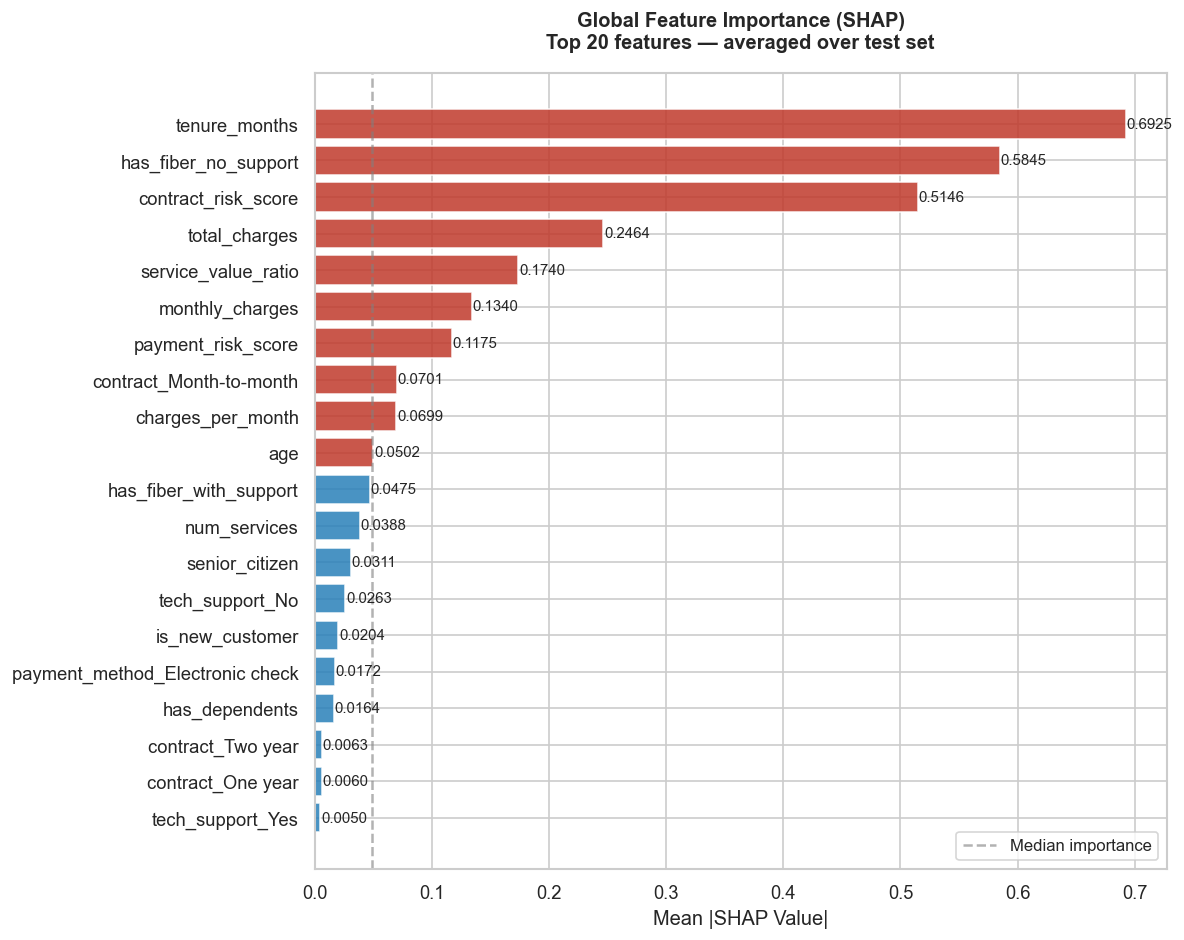


Top 5 most important features globally :
  tenure_months                       0.6925
  has_fiber_no_support                0.5845
  contract_risk_score                 0.5146
  total_charges                       0.2464
  service_value_ratio                 0.1740


In [ ]:
print("── GLOBAL FEATURE IMPORTANCE — BAR PLOT ──")
print("Mean absolute SHAP value across all test samples.")
print("This answers: which features matter most ON AVERAGE?\n")

fig, ax = plt.subplots(figsize=(10, 8))

# Compute mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature'    : proc_feature_names[:len(mean_abs_shap)],
    'importance' : mean_abs_shap
}).sort_values('importance', ascending=True).tail(20)

colors = [
    '#c0392b' if v > shap_importance['importance'].median()
    else '#2980b9'
    for v in shap_importance['importance']
]

bars = ax.barh(
    shap_importance['feature'],
    shap_importance['importance'],
    color=colors, alpha=0.85,
    edgecolor='white', linewidth=1
)

for bar, val in zip(bars, shap_importance['importance']):
    ax.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title(
    'Global Feature Importance (SHAP)\n'
    'Top 20 features — averaged over test set',
    fontweight='bold', pad=15
)
ax.axvline(
    x=shap_importance['importance'].median(),
    color='gray', linestyle='--', alpha=0.6,
    label='Median importance'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '20_shap_global_bar.png',
            bbox_inches='tight')
plt.show()

print(f"\nTop 5 most important features globally :")
top5 = shap_importance.sort_values(
    'importance', ascending=False
).head(5)
for _, row in top5.iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

── BEESWARM PLOT ──
Shows BOTH importance AND direction for each feature.
Red = high feature value, Blue = low feature value



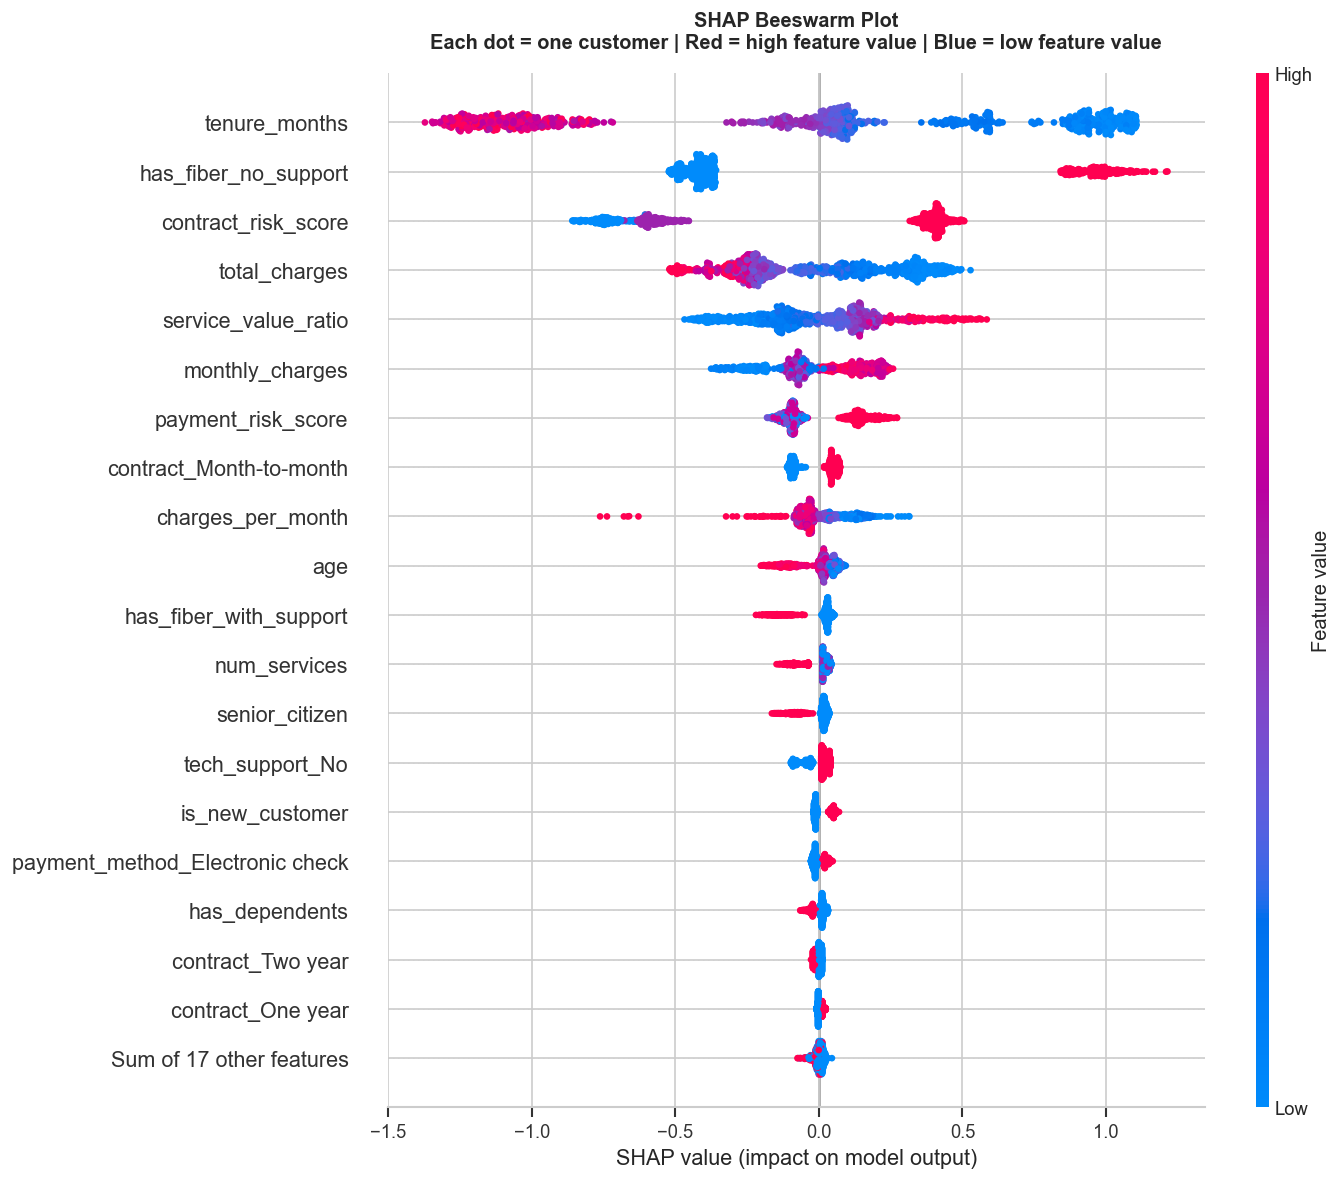

How to read this plot :
  → Features ordered by importance (top = most important)
  → Positive SHAP value = pushes toward churn
  → Negative SHAP value = pushes away from churn
  → Red dot + positive SHAP = high value increases churn
  → Blue dot + positive SHAP = low value increases churn


In [ ]:
print("── BEESWARM PLOT ──")
print("Shows BOTH importance AND direction for each feature.")
print("Red = high feature value, Blue = low feature value\n")

# Create SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values),
                        explainer.expected_value),
    data=X_test_sample,
    feature_names=proc_feature_names[:X_test_sample.shape[1]]
)

fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(
    explanation,
    max_display=20,
    show=False,
    plot_size=(12, 10)
)
plt.title(
    'SHAP Beeswarm Plot\n'
    'Each dot = one customer | '
    'Red = high feature value | Blue = low feature value',
    fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '21_shap_beeswarm.png',
            bbox_inches='tight')
plt.show()

print("How to read this plot :")
print("  → Features ordered by importance (top = most important)")
print("  → Positive SHAP value = pushes toward churn")
print("  → Negative SHAP value = pushes away from churn")
print("  → Red dot + positive SHAP = high value increases churn")
print("  → Blue dot + positive SHAP = low value increases churn")

── WATERFALL CHART — HIGH RISK CUSTOMER ──
Explains exactly WHY this specific customer
received a high churn probability.

Selected customer index  : 18
Churn probability        : 0.9700
Actual label             : CHURNED ✓


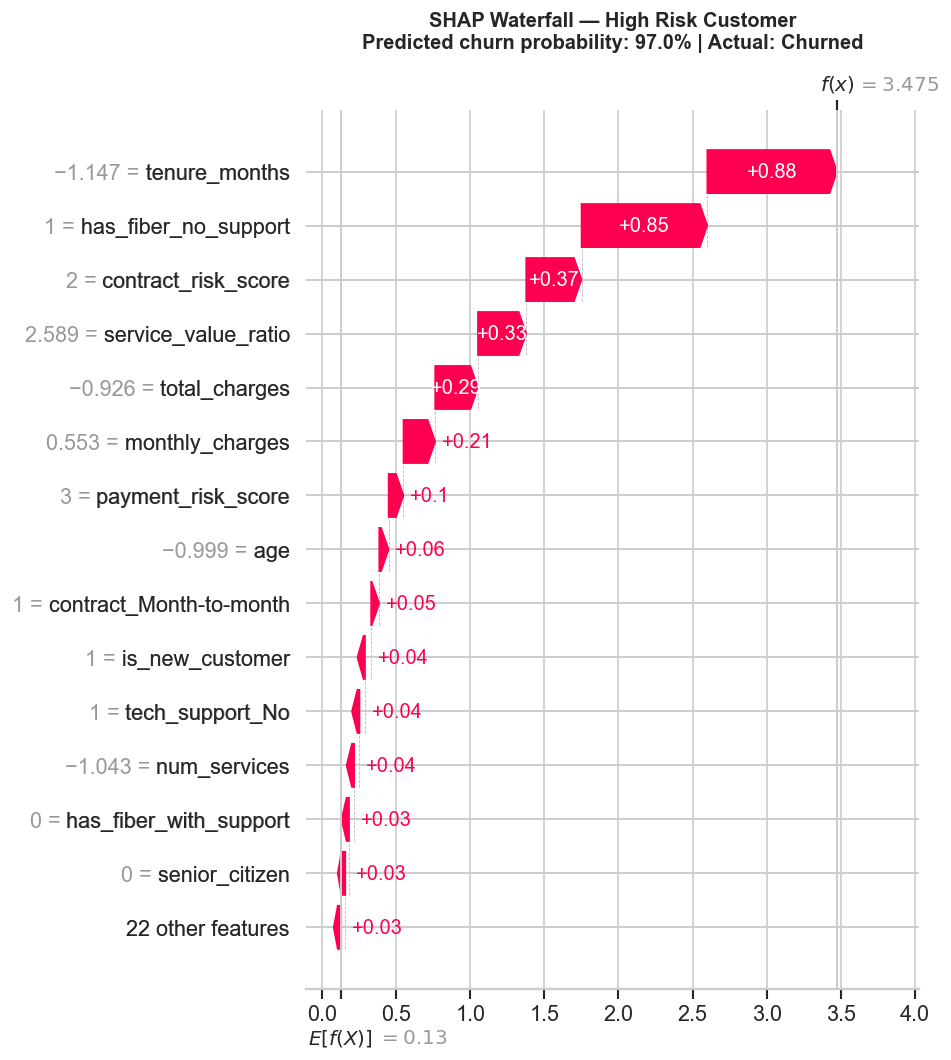


How to read the waterfall :
  → Starts from base value (average prediction)
  → Each bar = one feature's contribution
  → Red bars push probability UP (toward churn)
  → Blue bars push probability DOWN (away from churn)
  → Final value = model's prediction for this customer


In [8]:
print("── WATERFALL CHART — HIGH RISK CUSTOMER ──")
print("Explains exactly WHY this specific customer")
print("received a high churn probability.\n")

# Find a high-risk customer
y_proba_sample = model.predict_proba(X_test_sample)[:, 1]
high_risk_idx  = np.argsort(y_proba_sample)[-1]  # highest prob

high_risk_prob  = y_proba_sample[high_risk_idx]
high_risk_label = y_test_sample[high_risk_idx]

print(f"Selected customer index  : {high_risk_idx}")
print(f"Churn probability        : {high_risk_prob:.4f}")
print(f"Actual label             : "
      f"{'CHURNED ✓' if high_risk_label == 1 else 'STAYED'}")

# Waterfall plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(
    explanation[high_risk_idx],
    max_display=15,
    show=False
)
plt.title(
    f'SHAP Waterfall — High Risk Customer\n'
    f'Predicted churn probability: {high_risk_prob:.1%} | '
    f'Actual: {"Churned" if high_risk_label==1 else "Stayed"}',
    fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '22_shap_waterfall_high_risk.png',
            bbox_inches='tight')
plt.show()

print("\nHow to read the waterfall :")
print("  → Starts from base value (average prediction)")
print("  → Each bar = one feature's contribution")
print("  → Red bars push probability UP (toward churn)")
print("  → Blue bars push probability DOWN (away from churn)")
print("  → Final value = model's prediction for this customer")

── WATERFALL CHART — LOW RISK CUSTOMER ──
Selected customer index  : 29
Churn probability        : 0.0303
Actual label             : STAYED ✓


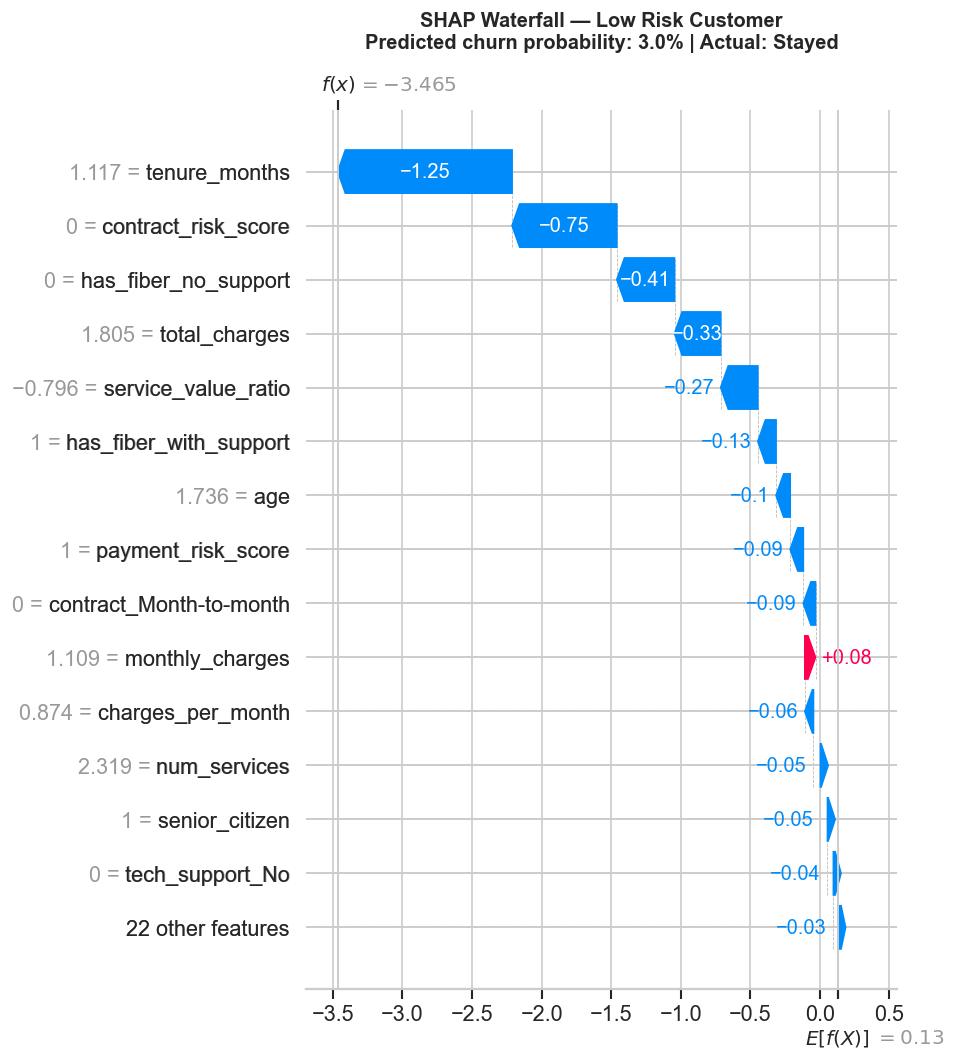

In [9]:
print("── WATERFALL CHART — LOW RISK CUSTOMER ──")

# Find a low-risk customer who actually stayed
stayed_mask   = y_test_sample == 0
low_risk_idx  = np.where(stayed_mask)[0][
    np.argmin(y_proba_sample[stayed_mask])
]

low_risk_prob  = y_proba_sample[low_risk_idx]
low_risk_label = y_test_sample[low_risk_idx]

print(f"Selected customer index  : {low_risk_idx}")
print(f"Churn probability        : {low_risk_prob:.4f}")
print(f"Actual label             : "
      f"{'CHURNED' if low_risk_label == 1 else 'STAYED ✓'}")

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(
    explanation[low_risk_idx],
    max_display=15,
    show=False
)
plt.title(
    f'SHAP Waterfall — Low Risk Customer\n'
    f'Predicted churn probability: {low_risk_prob:.1%} | '
    f'Actual: {"Churned" if low_risk_label==1 else "Stayed"}',
    fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '23_shap_waterfall_low_risk.png',
            bbox_inches='tight')
plt.show()

── WATERFALL CHART — FALSE NEGATIVE ──
A customer who churned but the model missed.
This is the most important failure case to understand.

False negative customer  : 42
Churn probability        : 0.3377
Threshold                : 0.47
→ Model predicted STAYED but customer CHURNED


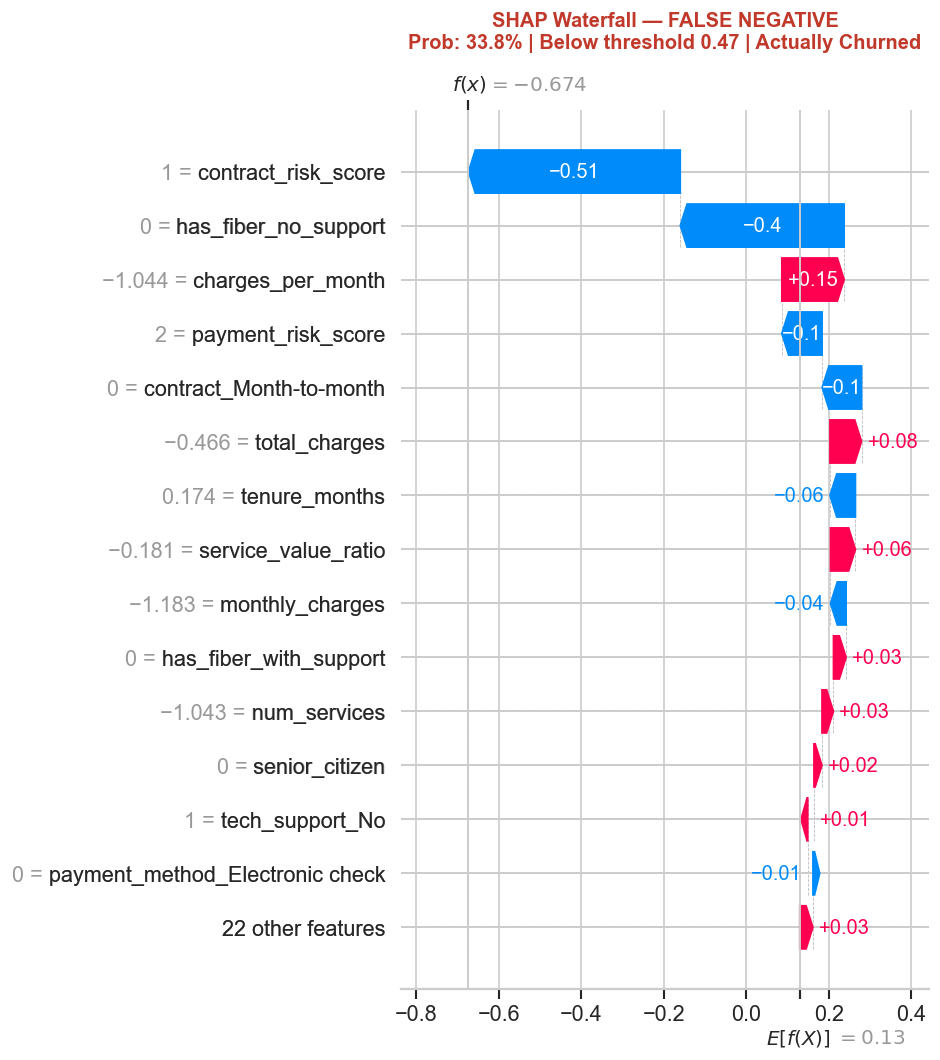


What this tells us :
  → Features that made the model confident this
    customer would stay despite churning
  → These are the model's blind spots
  → Useful for business — what signals did we miss?


In [10]:
print("── WATERFALL CHART — FALSE NEGATIVE ──")
print("A customer who churned but the model missed.")
print("This is the most important failure case to understand.\n")

threshold  = metadata['optimal_threshold']
y_pred_opt = (y_proba_sample >= threshold).astype(int)

# False negatives — actually churned but predicted as stayed
fn_mask = (y_test_sample == 1) & (y_pred_opt == 0)
fn_indices = np.where(fn_mask)[0]

if len(fn_indices) > 0:
    fn_idx   = fn_indices[0]
    fn_prob  = y_proba_sample[fn_idx]
    print(f"False negative customer  : {fn_idx}")
    print(f"Churn probability        : {fn_prob:.4f}")
    print(f"Threshold                : {threshold:.2f}")
    print(f"→ Model predicted STAYED but customer CHURNED")

    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(
        explanation[fn_idx],
        max_display=15,
        show=False
    )
    plt.title(
        f'SHAP Waterfall — FALSE NEGATIVE\n'
        f'Prob: {fn_prob:.1%} | Below threshold {threshold:.2f} | '
        f'Actually Churned',
        fontweight='bold', pad=15,
        color='#c0392b'
    )
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '24_shap_waterfall_false_negative.png',
                bbox_inches='tight')
    plt.show()

    print("\nWhat this tells us :")
    print("  → Features that made the model confident this")
    print("    customer would stay despite churning")
    print("  → These are the model's blind spots")
    print("  → Useful for business — what signals did we miss?")
else:
    print("No false negatives found in this sample.")

── SHAP DEPENDENCE PLOTS ──
Shows how a single feature's value relates to its SHAP value.
Reveals non-linear relationships the model learned.

Plotting dependence for : ['tenure_months', 'has_fiber_no_support', 'contract_risk_score']


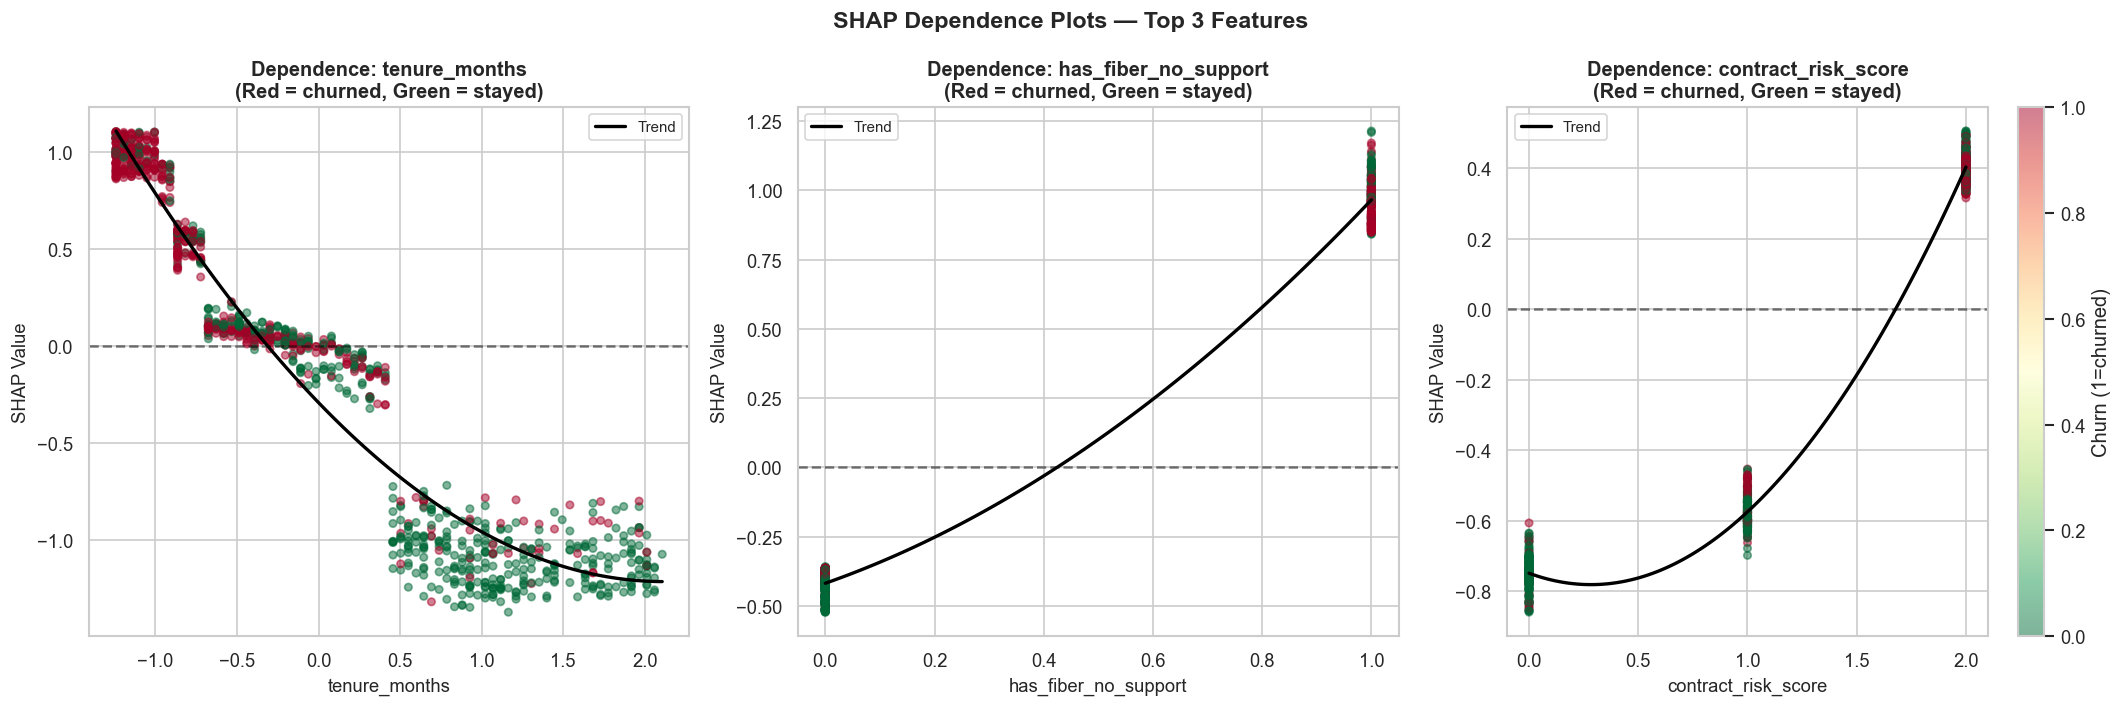

In [11]:
print("── SHAP DEPENDENCE PLOTS ──")
print("Shows how a single feature's value relates to its SHAP value.")
print("Reveals non-linear relationships the model learned.\n")

# Get top 3 features by importance
top3_features = (
    pd.DataFrame({
        'feature'    : proc_feature_names[:len(mean_abs_shap)],
        'importance' : mean_abs_shap
    })
    .sort_values('importance', ascending=False)
    .head(3)['feature']
    .tolist()
)

print(f"Plotting dependence for : {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature_name in enumerate(top3_features):
    # Find feature index in processed feature names
    if feature_name in proc_feature_names:
        feat_idx = proc_feature_names.index(feature_name)
    else:
        feat_idx = i

    feat_values  = X_test_sample[:, feat_idx]
    feat_shap    = shap_values[:, feat_idx]

    # Color by churn label
    scatter = axes[i].scatter(
        feat_values, feat_shap,
        c=y_test_sample,
        cmap='RdYlGn_r',
        alpha=0.5, s=20
    )
    axes[i].axhline(y=0, color='black',
                    linestyle='--', alpha=0.5)

    # Trend line
    z = np.polyfit(feat_values, feat_shap, deg=2)
    p = np.poly1d(z)
    x_line = np.linspace(feat_values.min(),
                          feat_values.max(), 100)
    axes[i].plot(x_line, p(x_line),
                 color='black', linewidth=2,
                 label='Trend')

    axes[i].set_xlabel(feature_name, fontsize=11)
    axes[i].set_ylabel('SHAP Value', fontsize=11)
    axes[i].set_title(
        f'Dependence: {feature_name}\n'
        f'(Red = churned, Green = stayed)',
        fontweight='bold'
    )
    axes[i].legend(fontsize=9)

plt.colorbar(scatter, ax=axes[-1],
             label='Churn (1=churned)')
plt.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '25_shap_dependence.png',
            bbox_inches='tight')
plt.show()

── SHAP SEGMENT ANALYSIS ──
Compare average SHAP contributions across customer segments.

Risk tier distribution :
risk_tier
High Risk      449
Low Risk       342
Medium Risk    209



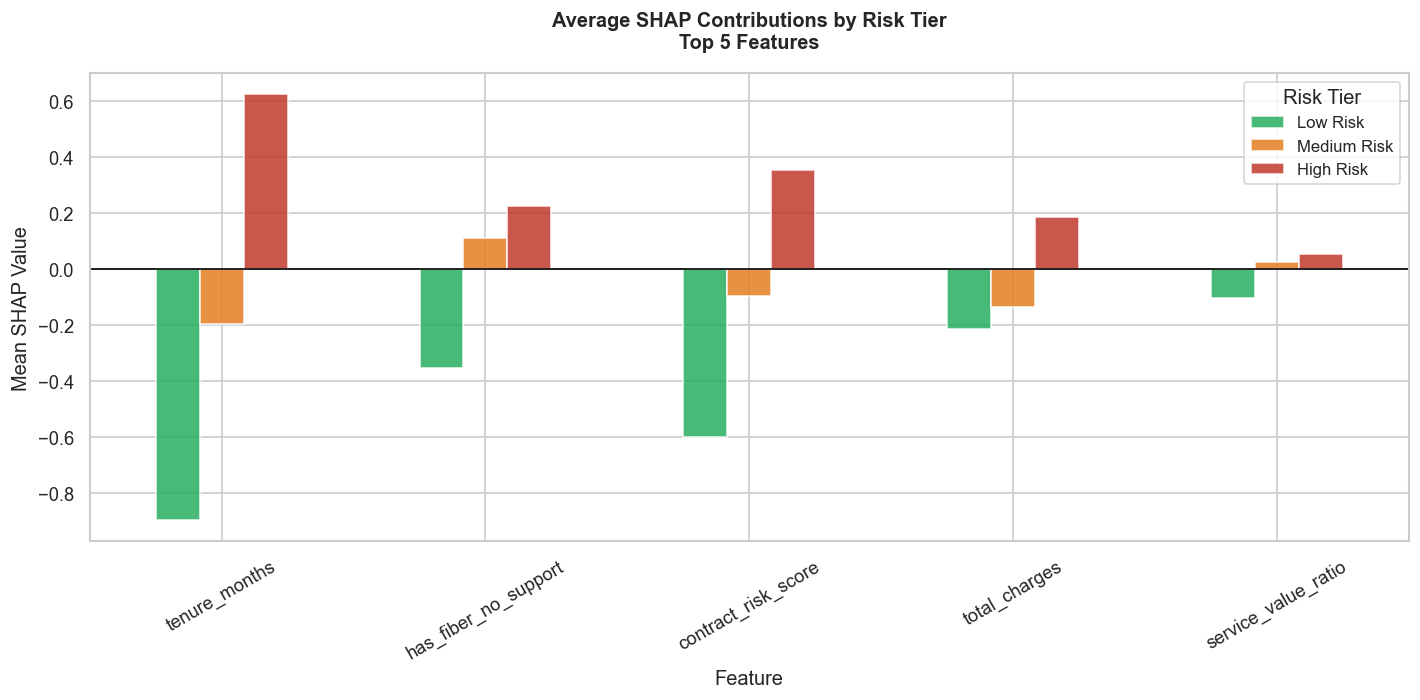

In [12]:
print("── SHAP SEGMENT ANALYSIS ──")
print("Compare average SHAP contributions across customer segments.\n")

# Rebuild with original feature columns for segmentation
X_test_original = X_test.iloc[sample_idx].copy()
X_test_original['churn_prob']  = y_proba_sample
X_test_original['actual_churn'] = y_test_sample

# Add risk tier
X_test_original['risk_tier'] = pd.cut(
    X_test_original['churn_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk tier distribution :")
print(X_test_original['risk_tier'].value_counts().to_string())
print()

# SHAP contributions by risk tier
shap_df_full = pd.DataFrame(
    shap_values,
    columns=proc_feature_names[:shap_values.shape[1]]
)
shap_df_full['risk_tier'] = X_test_original['risk_tier'].values

# Mean SHAP per tier for top 5 features
top5_feat = (
    pd.Series(mean_abs_shap,
              index=proc_feature_names[:len(mean_abs_shap)])
    .nlargest(5).index.tolist()
)

tier_shap = shap_df_full.groupby(
    'risk_tier', observed=True
)[top5_feat].mean()

fig, ax = plt.subplots(figsize=(12, 6))
tier_shap.T.plot(kind='bar', ax=ax,
                 color=['#27ae60', '#e67e22', '#c0392b'],
                 alpha=0.85, edgecolor='white',
                 linewidth=1)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Mean SHAP Value', fontsize=12)
ax.set_title(
    'Average SHAP Contributions by Risk Tier\n'
    'Top 5 Features',
    fontweight='bold', pad=15
)
ax.legend(title='Risk Tier', fontsize=10)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '26_shap_segment_analysis.png',
            bbox_inches='tight')
plt.show()

In [13]:
print("── API-READY EXPLAIN FUNCTION ──")
print("This exact function will be used in the FastAPI endpoint.\n")

def explain_prediction(
    customer_data: np.ndarray,
    explainer: shap.TreeExplainer,
    feature_names: list,
    top_n: int = 5
) -> dict:
    """
    Generate SHAP explanation for a single customer.

    Args:
        customer_data : preprocessed feature array, shape (1, n_features)
        explainer     : fitted shap.TreeExplainer
        feature_names : list of feature names after preprocessing
        top_n         : number of top features to return

    Returns:
        dict with base_value, prediction, and top feature impacts
    """
    shap_vals = explainer.shap_values(customer_data)

    # Handle single row
    if len(shap_vals.shape) > 1:
        shap_vals = shap_vals[0]

    # Build feature impact list
    feature_impacts = [
        {
            'feature'   : feature_names[i],
            'shap_value': round(float(shap_vals[i]), 4),
            'direction' : (
                'increases_churn_risk'
                if shap_vals[i] > 0
                else 'decreases_churn_risk'
            ),
            'abs_impact': abs(float(shap_vals[i]))
        }
        for i in range(len(shap_vals))
        if i < len(feature_names)
    ]

    # Sort by absolute impact
    feature_impacts.sort(
        key=lambda x: x['abs_impact'], reverse=True
    )
    # Remove helper field
    for item in feature_impacts:
        del item['abs_impact']

    # Prediction probability
    pred_prob = float(
        explainer.expected_value +
        sum(shap_vals)
    )
    # Clip to valid probability range
    pred_prob = max(0.0, min(1.0, pred_prob))

    return {
        'base_value'   : round(float(explainer.expected_value), 4),
        'shap_sum'     : round(float(sum(shap_vals)), 4),
        'top_features' : feature_impacts[:top_n],
        'all_features' : feature_impacts
    }


# Test the function on one customer
test_customer = X_test_sample[0:1]
explanation_result = explain_prediction(
    test_customer,
    explainer,
    proc_feature_names[:X_test_sample.shape[1]]
)

print("Test explanation output :")
print(f"  Base value  : {explanation_result['base_value']}")
print(f"  SHAP sum    : {explanation_result['shap_sum']}")
print(f"\n  Top 5 feature impacts :")
for feat in explanation_result['top_features']:
    print(f"    {feat['feature']:<30} "
          f"{feat['shap_value']:>+.4f}  "
          f"{feat['direction']}")

── API-READY EXPLAIN FUNCTION ──
This exact function will be used in the FastAPI endpoint.

Test explanation output :
  Base value  : 0.1296
  SHAP sum    : -1.0601

  Top 5 feature impacts :
    contract_risk_score            -0.5309  decreases_churn_risk
    has_fiber_no_support           -0.3805  decreases_churn_risk
    total_charges                  -0.2713  decreases_churn_risk
    service_value_ratio            +0.2526  increases_churn_risk
    monthly_charges                +0.2047  increases_churn_risk


In [ ]:
print("── SAVING SHAP EXPLAINER ──")

# Save explainer for use in the API
joblib.dump(explainer, MODELS_PATH / 'shap_explainer_v1.pkl')

# Save feature names after preprocessing
with open(MODELS_PATH / 'proc_feature_names.json', 'w') as f:
    json.dump(
        proc_feature_names[:X_test_sample.shape[1]], f,
        indent=2
    )

# Verify load
explainer_check = joblib.load(
    MODELS_PATH / 'shap_explainer_v1.pkl'
)
test_shap = explainer_check.shap_values(X_test_sample[0:1])
assert test_shap is not None

print("Artifacts saved in models/ :")
print("  shap_explainer_v1.pkl     ← TreeExplainer object")
print("  proc_feature_names.json   ← post-preprocessing names")
print()
print("Updated models/ directory :")
for f in sorted(MODELS_PATH.glob('*')):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<35} {size:>8.1f} KB")

print("\n Explainer verified and saved")

── SAVING SHAP EXPLAINER ──
Artifacts saved in models/ :
  shap_explainer_v1.pkl     ← TreeExplainer object
  proc_feature_names.json   ← post-preprocessing names

Updated models/ directory :
  model_metadata.json                      1.8 KB
  preprocessor_v1.pkl                      4.9 KB
  proc_feature_names.json                  0.9 KB
  shap_explainer_v1.pkl                  459.9 KB
  xgboost_v1.pkl                         143.5 KB

✓ Explainer verified and saved


In [16]:
print("═" * 60)
print("  EXPLAINABILITY REPORT SUMMARY")
print("═" * 60)

print(f"\nModel              : {metadata['model_name']}")
print(f"AUC-ROC            : {metadata['auc_roc']}")
print(f"Optimal Threshold  : {metadata['optimal_threshold']}")
print(f"Base Value (E[f])  : {explainer.expected_value:.4f}")
print(f"  → Average prediction = {explainer.expected_value:.1%} churn")

print(f"\nTop 10 Global Features by Mean |SHAP| :")
top10 = (
    pd.DataFrame({
        'feature'    : proc_feature_names[:len(mean_abs_shap)],
        'importance' : mean_abs_shap
    })
    .sort_values('importance', ascending=False)
    .head(10)
)
for _, row in top10.iterrows():
    bar = '█' * int(row['importance'] * 300)
    print(f"  {row['feature']:<30} {row['importance']:.4f}  {bar}")

print(f"\nVisualisations saved :")
for fig_file in sorted(FIGURES_PATH.glob('2[0-6]_shap*.png')):
    print(f"  {fig_file.name}")



════════════════════════════════════════════════════════════
  EXPLAINABILITY REPORT SUMMARY
════════════════════════════════════════════════════════════

Model              : xgboost_v1
AUC-ROC            : 0.861
Optimal Threshold  : 0.47
Base Value (E[f])  : 0.1296
  → Average prediction = 13.0% churn

Top 10 Global Features by Mean |SHAP| :
  tenure_months                  0.6925  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  has_fiber_no_support           0.5845  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  contract_risk_score            0.5146  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████